<a href="https://colab.research.google.com/github/TemitopeAlawode/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TemitopeAlawode/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract

> This project investigates which observed search and content signals are associated with page performance, using a 30,000-page dataset of real search data from the FlyRank ML Internship. I built and compared three ML methods (Logistic Regression, Decision Tree, and Random Forest) against a hand-written baseline rule, finding that Logistic Regression achieved 70% precision at the top 50 recommendations, slightly improving over the baseline's 68%. The final output is a ranked action playbook that helps content teams prioritize which pages to review first. This is an observational, decision-support analysis, it shows what we observed in this dataset, not a guarantee of future performance.

## Introduction

Content teams face a common challenge: they can only review a limited number of pages, but they don't know which ones need attention most. Common assumptions like "high search volume means more traffic" or "longer content ranks better" are often wrong.

This project investigates which safe, observable signals (position, CTR, engagement, content age, word count, and consistency) are most strongly associated with a page's visibility and trajectory. The goal is to provide evidence-backed recommendations that help teams prioritize their limited time on pages that are most likely to need attention.

The decision this supports: "Which pages should I review first, and why?"

## 1. Question

*The research question and the decision it supports.*

### Research Question

**"Which observed search and content signals are associated with page performance?"**

This project investigates which safe, observable signals (position, CTR, engagement, content age, word count, and consistency) are most strongly associated with a page's visibility and trajectory.

### The Decision This Supports

This work helps content teams answer a practical question:

> *"Which pages should I review first, and why?"*

Rather than guessing which signals matter, teams can use evidence from the data to prioritize their limited time on pages that are most likely to need attention.

### Why This Question Matters

- **Common assumptions are often wrong:** Search volume had near-zero correlation (0.001) with actual page traffic in this dataset.
- **Signals are complex:** Multiple signals (position, CTR, engagement, age) interact in ways that are hard to see without systematic analysis.
- **Time is limited:** Content teams can only review a small number of pages — they need to focus on the ones that matter most.

### What This Work Does

| Question | How This Work Answers It |
|---|---|
| Which signals matter? | Signal analysis + feature importance from Random Forest |
| How do they interact? | Decision tree shows the interactions |
| Which pages need review? | Logistic Regression ranks pages by decline risk |
| What should teams do? | Action playbook provides ranked actions + reason codes |

### Honest Framing

This is an **observational, decision-support** analysis. It shows what we observed in this dataset, not what will definitely happen on every page. It is designed to **support** human decision-making, not replace it.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:
# ============================================================
# Setup: Import Libraries and Load Data
# ============================================================

import os, sys, subprocess
import pandas as pd
import numpy as np

# Setup for Colab
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

print("Working dir:", os.getcwd())

# ============================================================
# 2. Data — Load and Verify
# ============================================================

# Load the data
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Create label
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

print("=" * 60)
print("Data Summary")
print("=" * 60)

print(f"\nTotal pages: {len(df):,}")
print(f"Total clients: {df['client_id'].nunique():,}")
print(f"Declining rate: {df['is_declining_label'].mean():.3f}")

print(f"\nKey columns:")
key_cols = ['content_id', 'client_id', 'impressions_90d', 'ctr', 'avg_position',
            'engagement_rate', 'content_age_days', 'word_count', 'trend_direction']
for col in key_cols:
    non_null = df[col].notna().sum()
    print(f"  - {col}: {non_null:,} non-null")

print(f"\nExcluded columns (leakage prevention):")
excluded = ['trend_pct', 'trend_direction']
for col in excluded:
    if col in df.columns:
        print(f"  - {col}: EXCLUDED (would leak the label)")

print(f"\nUnit of analysis: One row = one content page")
print(f"Verified: {df['content_id'].nunique() == len(df)} — one row per page")

Working dir: /content/flyrank-ml-internship-starter
Data Summary

Total pages: 30,000
Total clients: 32
Declining rate: 0.542

Key columns:
  - content_id: 30,000 non-null
  - client_id: 30,000 non-null
  - impressions_90d: 30,000 non-null
  - ctr: 30,000 non-null
  - avg_position: 30,000 non-null
  - engagement_rate: 30,000 non-null
  - content_age_days: 30,000 non-null
  - word_count: 22,301 non-null
  - trend_direction: 30,000 non-null

Excluded columns (leakage prevention):
  - trend_pct: EXCLUDED (would leak the label)
  - trend_direction: EXCLUDED (would leak the label)

Unit of analysis: One row = one content page
Verified: True — one row per page


### Dataset Source

This analysis uses the **FlyRank ML Internship starter dataset**, which is an anonymized export of real search and content performance data.

| Dataset Property | Details |
|---|---|
| **Name** | `content_refresh_anonymized.csv` |
| **Rows** | 30,000 pages |
| **Clients** | 32 pseudonymized clients |
| **Columns** | 44 columns |
| **Time Window** | Trailing 90-day metrics |
| **Unit of Analysis** | One row = one content page |

### What the Data Contains

The dataset includes observed, pre-decision signals only:

| Signal Type | Examples |
|---|---|
| **Performance** | Impressions, clicks, sessions, CTR, average position |
| **Content** | Word count, content age, days since last update, content type |
| **Engagement** | Engagement rate, scroll rate |
| **Keyword** | Search volume, competition, CPC |

### What Was Excluded (Leakage Prevention)

| Excluded Field | Why Excluded |
|---|---|
| `trend_pct` | Derived from the label — would leak the answer |
| `trend_direction` | Derived from the label — would leak the answer |
| `content_id` | Identifier, not a signal |
| `client_id` | Used only for splitting, never as a feature |

### Data Verification

| Check | Result |
|---|---|
| Total pages | 30,000 |
| Total clients | 32 |
| Declining rate | 54.2% |
| One row per page? | ✅ True |

### Public-Safe

All client names, domains, URLs, and raw queries were pseudonymized or removed before release. No private data appears in this analysis.

### Data Access

The dataset is available in the starter repo:
`data/raw/content_refresh_anonymized.csv`

For the full 79M-row warehouse release, see:
[FlyRank Internship Warehouse](https://huggingface.co/datasets/FlyRank/internship-warehouse)

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Assumptions

This analysis is built on two core assumptions:

1. **Features are knowable at decision time** — All features come from the feature window (past data) and are available before any prediction is made.
2. **Labels are observed outcomes** — The label is derived from observed performance data, not from a product rule or decision.

### Features

I used an expanded feature set of **14 features** (10 numeric + 4 categorical), all knowable at decision time:

**Numeric Features (10):**

| Feature | Description |
|---|---|
| `avg_position` | Average search result position |
| `ctr` | Click-through rate |
| `engagement_rate` | Visitor engagement level |
| `content_age_days` | Age of the content in days |
| `word_count` | Number of words on the page |
| `search_volume` | Keyword search volume |
| `competition` | Keyword competition level |
| `days_since_last_update` | Days since the page was last updated |
| `scroll_rate` | How far users scroll on the page |
| `days_with_impressions` | Number of days the page appeared in search results |

**Categorical Features (4):**

| Feature | Description |
|---|---|
| `content_type` | Type of page (keyword article, feedly article, comparison article) |
| `main_intent` | User intent (informational, transactional, commercial, navigational) |
| `impression_tier` | Impression bucket (good, moderate, low) |
| `position_tier` | Position bucket (top_3, page_1, striking, page_3_5, deep) |

### Label Definition

**Label:** `is_declining_label`

| Value | Meaning |
|---|---|
| 1 | Page is declining (traffic trend is down) |
| 0 | Page is not declining (stable, up, or new) |

**Source:** Derived from `trend_direction == "down"` which is computed from `trend_pct`.

**⚠️ Leakage Prevention:** `trend_pct` and `trend_direction` are **NEVER used as features**.

### Baseline Rule

A simple hand-written rule created before any modeling:

> *"A page is worth reviewing if it's stale (no update in 180+ days) AND visible (500+ impressions in 90 days). Rank by total impressions."*

**Why 180 days?** This is a human-readable rule (6 months without an update). It follows FlyRank's existing refresh flag threshold and was chosen **without peeking at the data** to optimize the threshold.

### Models

I trained and compared **three models**:

| Model | Why Used |
|---|---|
| **Logistic Regression** | Interpretable — gives coefficients showing direction (+/-) of each signal |
| **Decision Tree (depth 3)** | Readable — produces a flowchart of yes/no questions |
| **Random Forest** | Stronger performance — gives feature importance |

### Validation Design

**Split Type:** Client-Holdout (80/20 split by client_id)

| Split | Rows | Clients |
|---|---|---|
| Training | 23,837 (80%) | 80% of clients |
| Testing | 6,163 (20%) | 20% of clients (completely unseen) |

**Why client-holdout?**
- Prevents the model from memorizing client-specific patterns
- Tests whether the model generalizes to new clients
- Matches real-world deployment (new clients will be unseen)

**Comparison: Random Split vs Client-Holdout**

| Split Type | Precision@20 | Precision@50 |
|---|---|---|
| Random (dishonest) | 0.700 | 0.740 |
| Client-Holdout (honest) | 0.650 | 0.700 |
| **Gap** | **+0.050** | **+0.040** |

The small gap confirms that the model generalizes well to new clients without memorizing client-specific patterns.

### Leakage Checks

All three leakage types were checked and passed:

| Leakage Type | Check | Result |
|---|---|---|
| **Label-derived** | Are any features derived from the label? | ✅ None — `trend_pct` and `trend_direction` excluded |
| **Future/overlapping** | Do any features use future data? | ✅ All features are from the feature window (past) |
| **Decision-derived** | Are any product flags used as features? | ✅ No product flags in the data |

### Evaluation Metric

**Precision@K** — of the top K pages recommended, what fraction are actually declining?

**Why Precision@K?**
- Matches real-world decision-making (content teams review K pages)
- Focuses on the quality of top recommendations
- More honest than overall accuracy (which can be inflated by the base rate)

**Base Rate:** 54.2% of all pages are declining. This is the "dumb guess" baseline — any model must beat this to be useful.

In [ ]:
# ============================================================
# 3. Methodology - Load Models and Show Evidence
# ============================================================

print("=" * 60)
print("Methodology Summary")
print("=" * 60)

print("\n--- Features ---")
print("Numeric features (10):")
numeric_features = [
    'avg_position', 'ctr', 'engagement_rate', 'content_age_days',
    'word_count', 'search_volume', 'competition', 'days_since_last_update',
    'scroll_rate', 'days_with_impressions'
]
for f in numeric_features:
    print(f"  - {f}")

print("\nCategorical features (4):")
categorical_features = ['content_type', 'main_intent', 'impression_tier', 'position_tier']
for f in categorical_features:
    print(f"  - {f}")

print(f"\nTotal features: {len(numeric_features) + len(categorical_features)}")

print("\n--- Label ---")
print("Label: is_declining_label (1 = declining, 0 = not declining)")
print(f"  Declining rate: {df['is_declining_label'].mean():.3f}")

print("\n--- Baseline Rule ---")
print("score = stale × visible × impressions")
print("  stale = days_since_last_update >= 180")
print("  visible = impressions_90d >= 500")

# Create the baseline score
stale = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
df["baseline_score"] = stale * visible * df["impressions_90d"]

print(f"  Pages captured: {(df['baseline_score'] > 0).sum()}")

print("\n--- Models ---")
print("1. Logistic Regression (interpretable — coefficients)")
print("2. Decision Tree (readable — flowchart)")
print("3. Random Forest (feature importance)")

print("\n--- Validation ---")
print("Split: Client-Holdout (80/20 by client_id)")
print("Training: 23,837 rows")
print("Testing: 6,163 rows")

print("\n--- Leakage Checks ---")
print("✅ No label-derived columns used as features")
print("✅ No future-window data used")
print("✅ No product flags used as features")

print("\n--- Evaluation Metric ---")
print("Precision@20 and Precision@50")
print(f"Base Rate: {df['is_declining_label'].mean():.3f}")

Methodology Summary

--- Features ---
Numeric features (10):
  - avg_position
  - ctr
  - engagement_rate
  - content_age_days
  - word_count
  - search_volume
  - competition
  - days_since_last_update
  - scroll_rate
  - days_with_impressions

Categorical features (4):
  - content_type
  - main_intent
  - impression_tier
  - position_tier

Total features: 14

--- Label ---
Label: is_declining_label (1 = declining, 0 = not declining)
  Declining rate: 0.542

--- Baseline Rule ---
score = stale × visible × impressions
  stale = days_since_last_update >= 180
  visible = impressions_90d >= 500
  Pages captured: 17

--- Models ---
1. Logistic Regression (interpretable — coefficients)
2. Decision Tree (readable — flowchart)
3. Random Forest (feature importance)

--- Validation ---
Split: Client-Holdout (80/20 by client_id)
Training: 23,837 rows
Testing: 6,163 rows

--- Leakage Checks ---
✅ No label-derived columns used as features
✅ No future-window data used
✅ No product flags used as fea

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Comparison Table

All models were evaluated on the same client-holdout test set (20% of clients, completely unseen during training). The baseline is the hand-written rule from Week 4.

| Method | Precision@20 | Precision@50 |
|---|---|---|
| Baseline (my rule) | **0.900** | 0.680 |
| Logistic Regression | 0.650 | **0.700** |
| Decision Tree | 0.550 | 0.480 |
| Random Forest | 0.450 | 0.620 |

*Base Rate (overall declining rate): 0.542*

### Key Findings

#### 1. Baseline Dominates at the Top

The simple rule (`stale × visible × impressions`) achieves **90% precision at top 20** — meaning 18 of the top 20 recommendations are actually declining pages. This shows that the combination of **staleness (180+ days)** and **visibility (500+ impressions)** is an exceptionally strong signal for finding the most critical pages.

#### 2. Logistic Regression Wins at Scale

At top 50, Logistic Regression achieves **70% precision**, slightly beating the baseline (68%). This means it identifies **35 correct pages** vs the baseline's 34 — a small but real improvement. The expanded feature set (14 features including `scroll_rate`, `days_with_impressions`, and position/impression tiers) helped the model find **additional declining pages** beyond what the simple rule captures.

#### 3. Decision Tree and Random Forest Underperformed

Both tree-based models performed worse than the baseline, possibly due to:
- Overfitting to training data
- The depth constraint (Decision Tree limited to depth 3)
- Noise in additional features confusing the models

### What the Models Learned

**Feature Importance (Random Forest):**

| Rank | Feature | Importance |
|---|---|---|
| 1 | `avg_position` | **0.156** |
| 2 | `days_with_impressions` | 0.133 |
| 3 | `content_age_days` | 0.124 |
| 4 | `word_count` | 0.108 |
| 5 | `ctr` | 0.091 |

**Key insight:** Position is the #1 predictor of decline, followed by consistency and age.

**Logistic Regression Coefficients (Top 5):**

| Feature | Coefficient | Direction |
|---|---|---|
| `position_tier_top_3` | -1.019 | DECREASES decline |
| `impression_tier_excellent` | -0.770 | DECREASES decline |
| `days_with_impressions` | +0.636 | INCREASES decline |
| `impression_tier_low` | +0.531 | INCREASES decline |
| `content_age_days` | -0.431 | DECREASES decline |

**Key insight:** Being in the top 3 position is the most protective factor against decline. Consistency of visibility has mixed effects — it may indicate pages that are visible but losing traction.

### Error Analysis

| Metric | Value |
|---|---|
| Total errors | 2,745 out of 6,163 (44.5%) |
| False Positives | 1,092 (predicted decline, actually stable) |
| False Negatives | 1,653 (predicted stable, actually declining) |

**Key insight:** The model makes more false negatives (misses declining pages) than false positives (falsely flags stable pages). It is conservative — it prefers to say "stable" even when wrong.

### Honest Conclusion

**Use both:**
- **Baseline rule** for the **top 20** (highest precision)
- **Logistic Regression** for the **next 30** (better coverage)

The baseline rule remains a strong, simple option — especially when only the most critical pages are needed. However, Logistic Regression with expanded features can identify additional declining pages when more candidates are required.

> *"My baseline rule performed exceptionally well at the top 20 (90% precision), beating all models. However, Logistic Regression slightly improved performance at the top 50 (70% vs 68%), suggesting it can identify additional declining pages that the simple rule misses. This shows that while the rule is excellent for finding the most critical pages, a learned model can expand coverage."*

In [ ]:
# ============================================================
# 4. Results - Show Comparison Table
# ============================================================

print("=" * 60)
print("Results: Model vs Baseline")
print("=" * 60)

# Results from Week 5
results = {
    "Baseline (my rule)": {"Precision@20": 0.900, "Precision@50": 0.680},
    "Logistic Regression": {"Precision@20": 0.650, "Precision@50": 0.700},
    "Decision Tree": {"Precision@20": 0.550, "Precision@50": 0.480},
    "Random Forest": {"Precision@20": 0.450, "Precision@50": 0.620}
}

print("\nComparison Table:")
print("-" * 70)
print(f"{'Method':<22} {'Precision@20':<14} {'Precision@50':<14}")
print("-" * 70)

for method, metrics in results.items():
    print(f"{method:<22} {metrics['Precision@20']:<14.3f} {metrics['Precision@50']:<14.3f}")

print("-" * 70)
print(f"\nBase Rate (overall declining rate): 0.542")

print("\n" + "=" * 60)
print("Key Findings")
print("=" * 60)

print("\n1. Baseline dominates at top 20")
print("   → 0.900 vs 0.650 (Logistic Regression)")
print("   → The simple rule is excellent at finding the worst pages")

print("\n2. Logistic Regression wins at top 50")
print("   → 0.700 vs 0.680 (Baseline)")
print("   → The model finds MORE bad pages than the simple rule")

print("\n3. Tree models underperformed")
print("   → Decision Tree: 0.550 at P@20")
print("   → Random Forest: 0.450 at P@20")
print("   → Possibly overfitting or too shallow")

print("\n" + "=" * 60)
print("Feature Importance (Random Forest)")
print("=" * 60)

print("\nTop 5 Features:")
importance = {
    "avg_position": 0.156,
    "days_with_impressions": 0.133,
    "content_age_days": 0.124,
    "word_count": 0.108,
    "ctr": 0.091
}

for rank, (feature, imp) in enumerate(importance.items(), 1):
    print(f"  {rank}. {feature}: {imp:.3f}")

print("\nKey insight: Position is the #1 predictor of decline.")

print("\n" + "=" * 60)
print("Error Analysis")
print("=" * 60)

print("\nLogistic Regression Errors:")
print("  Total errors: 2,745 out of 6,163 (44.5%)")
print("  False Positives: 1,092 (predicted decline, actually stable)")
print("  False Negatives: 1,653 (predicted stable, actually declining)")

print("\nKey insight: The model is conservative — it misses more declining pages than it falsely flags.")

Results: Model vs Baseline

Comparison Table:
----------------------------------------------------------------------
Method                 Precision@20   Precision@50  
----------------------------------------------------------------------
Baseline (my rule)     0.900          0.680         
Logistic Regression    0.650          0.700         
Decision Tree          0.550          0.480         
Random Forest          0.450          0.620         
----------------------------------------------------------------------

Base Rate (overall declining rate): 0.542

Key Findings

1. Baseline dominates at top 20
   → 0.900 vs 0.650 (Logistic Regression)
   → The simple rule is excellent at finding the worst pages

2. Logistic Regression wins at top 50
   → 0.700 vs 0.680 (Baseline)
   → The model finds MORE bad pages than the simple rule

3. Tree models underperformed
   → Decision Tree: 0.550 at P@20
   → Random Forest: 0.450 at P@20
   → Possibly overfitting or too shallow

Feature Importa

## 5. Limitations

*What this work cannot claim.*

### What This Work Cannot Claim

This analysis is observational. Every claim in this paper is **observed, measured, directional, and decision-support** - not causal.

| Limitation | Explanation |
|---|---|
| **No causation** | We observed associations between signals and decline, but we did NOT prove that changing a signal will cause a page to recover. Correlation ≠ causation. |
| **Historical data** | The analysis is based on the starter dataset (March-June 2026). Patterns may shift over time as search algorithms, user behavior, and content strategies change. |
| **Small sample** | The starter dataset has 30,000 pages from 32 clients. Patterns observed here may differ in larger datasets or different industries. |
| **No manual review** | The model flags pages worth reviewing — it does NOT replace human judgment. Always verify recommendations with manual review before taking action. |
| **Not production code** | This is a decision-support playbook, not an automated system. It is designed to support human decision-making, not replace it. |

### What I Can Claim

| Claim | Evidence |
|---|---|
| **In this dataset, position is the strongest predictor of decline** | Random Forest feature importance (0.156) |
| **In this dataset, Logistic Regression outperformed the baseline at Precision@50** | 0.700 vs 0.680 |
| **In this dataset, the baseline rule outperformed all models at Precision@20** | 0.900 vs 0.650 |
| **Observed patterns suggest that stale, visible pages are prime refresh candidates** | Signal audit + model results |
| **The model is conservative — it misses more declining pages than it falsely flags** | Error analysis: 1,653 false negatives vs 1,092 false positives |

### Honest Statement

> "This work shows what we observed in this dataset, not what will happen on every page. It is designed to support human decision-making, not replace it. Always verify recommendations before acting."

In [ ]:
# ============================================================
# 5. Limitations - Show the Honest Boundaries
# ============================================================

print("=" * 60)
print("Limitations: What This Work Cannot Claim")
print("=" * 60)

print("\nThis analysis is observational. Every claim in this paper is")
print("observed, measured, directional, and decision-support — not causal.\n")

print("Limitations:")
print("-" * 50)

limitations = [
    ("No causation", "We observed associations, but we did NOT prove that changing a signal will cause a page to recover."),
    ("Historical data", "Based on the starter dataset (March-June 2026). Patterns may shift over time."),
    ("Small sample", "30,000 pages from 32 clients — patterns may differ in larger datasets."),
    ("No manual review", "The model flags pages — it does NOT replace human judgment."),
    ("Not production code", "This is a decision-support playbook, not an automated system.")
]

for i, (title, desc) in enumerate(limitations, 1):
    print(f"\n{i}. {title}")
    print(f"   → {desc}")

print("\n" + "=" * 60)
print("What I Can Claim")
print("=" * 60)

claims = [
    ("In this dataset, position is the strongest predictor of decline", "Random Forest feature importance (0.156)"),
    ("In this dataset, Logistic Regression outperformed the baseline at Precision@50", "0.700 vs 0.680"),
    ("In this dataset, the baseline rule outperformed all models at Precision@20", "0.900 vs 0.650"),
    ("Observed patterns suggest that stale, visible pages are prime refresh candidates", "Signal audit + model results"),
    ("The model is conservative — it misses more declining pages than it falsely flags", "Error analysis: 1,653 false negatives vs 1,092 false positives")
]

for i, (claim, evidence) in enumerate(claims, 1):
    print(f"\n{i}. {claim}")
    print(f"   → Evidence: {evidence}")

print("\n" + "=" * 60)
print("Honest Statement")
print("=" * 60)

print()
print('"This work shows what we observed in this dataset,')
print(' not what will happen on every page."')
print('"It is designed to support human decision-making,')
print(' not replace it. Always verify recommendations before acting."')

Limitations: What This Work Cannot Claim

This analysis is observational. Every claim in this paper is
observed, measured, directional, and decision-support — not causal.

Limitations:
--------------------------------------------------

1. No causation
   → We observed associations, but we did NOT prove that changing a signal will cause a page to recover.

2. Historical data
   → Based on the starter dataset (March-June 2026). Patterns may shift over time.

3. Small sample
   → 30,000 pages from 32 clients — patterns may differ in larger datasets.

4. No manual review
   → The model flags pages — it does NOT replace human judgment.

5. Not production code
   → This is a decision-support playbook, not an automated system.

What I Can Claim

1. In this dataset, position is the strongest predictor of decline
   → Evidence: Random Forest feature importance (0.156)

2. In this dataset, Logistic Regression outperformed the baseline at Precision@50
   → Evidence: 0.700 vs 0.680

3. In this da

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Based on the model results and signal analysis, I created a ranked action playbook for content teams. Each action includes a reason code, definition, and practical next step.

### Priority 1: Review Declining Pages with High Traffic

> **Action:** Review pages that are losing traffic but still have significant visibility.

| Element | Detail |
|---|---|
| **Reason Code** | `declining_visible` |
| **Definition** | `is_declining_label == 1` AND `impressions_90d >= 500` |
| **Count** | 4,676 pages |
| **What to do** | Read the page, identify why it's declining (competition? outdated content? intent shift?), and plan an update. |
| **Why this priority** | These pages are actively losing traffic. The sooner they're reviewed, the sooner you can reverse the decline. |

---

### Priority 2: Fix CTR on Page 1 Pages

> **Action:** Improve titles and meta descriptions on pages that already rank well.

| Element | Detail |
|---|---|
| **Reason Code** | `low_ctr_visible` |
| **Definition** | `avg_position <= 10` AND `ctr < 0.3` AND `impressions_90d >= 100` |
| **Count** | 4,435 pages |
| **What to do** | Rewrite the title tag and meta description to better match search intent and encourage clicks. |
| **Why this priority** | These pages already have good positions — improving CTR will immediately increase traffic without needing a ranking boost. |

---

### Priority 3: Monitor Striking Distance Pages

> **Action:** Watch pages that are close to page 1.

| Element | Detail |
|---|---|
| **Reason Code** | `striking_distance` |
| **Definition** | `avg_position BETWEEN 11 AND 20` AND `impressions_90d >= 100` |
| **Count** | 3,840 pages |
| **What to do** | Monitor their position. If they start dropping, review them before they fall further. |
| **Why this priority** | These pages are on the edge — small improvements could push them onto page 1. |

---

### Priority 4: Expand Thin Visible Pages

> **Action:** Add content to pages that get views but are too short.

| Element | Detail |
|---|---|
| **Reason Code** | `thin_visible_page` |
| **Definition** | `word_count < 1200` AND `impressions_90d >= 250` |
| **Count** | 72 pages |
| **What to do** | Add missing subtopics, examples, definitions, and supporting evidence. |
| **Why this priority** | These pages are already visible — expanding them makes them more competitive. |

---

### Priority 5: Refresh Stale Pages with Traffic

> **Action:** Refresh pages that haven't been updated in 6+ months but still get traffic.

| Element | Detail |
|---|---|
| **Reason Code** | `stale_visible_page` |
| **Definition** | `days_since_last_update >= 180` AND `impressions_90d >= 500` |
| **Count** | 1 page |
| **What to do** | Update outdated facts, add missing subtopics, refresh statistics, and improve readability. |
| **Why this priority** | These pages have demand but are old. A refresh can bring back lost traffic. |

---

### Quick Reference Table

| Priority | Action | Reason Code | Count | Key Signal |
|---|---|---|---|---|
| 1 | Review declining visible pages | `declining_visible` | 4,676 | Declining + High Impressions |
| 2 | Fix CTR on page 1 pages | `low_ctr_visible` | 4,435 | Good Position + Low CTR |
| 3 | Monitor striking distance pages | `striking_distance` | 3,840 | Positions 11-20 |
| 4 | Expand thin visible pages | `thin_visible_page` | 72 | Thin + Visible |
| 5 | Refresh stale visible pages | `stale_visible_page` | 1 | Stale + High Impressions |

### Key Insight

The largest opportunities in this dataset are:
1. **Declining visible pages** (4,676) — urgent review needed
2. **Page 1 pages with low CTR** (4,435) — quick wins available

The `stale_visible_page` action only applies to **1 page**, meaning pages in this dataset are either being updated regularly or lose visibility before they become stale.

In [ ]:
# ============================================================
# 6. Ranked Recommendations - Load Action Playbook
# ============================================================

print("=" * 60)
print("Ranked Recommendations")
print("=" * 60)

# Define the actions
actions = [
    {
        "Priority": 1,
        "Action": "Review declining visible pages",
        "Reason Code": "declining_visible",
        "Definition": "is_declining_label == 1 AND impressions_90d >= 500",
        "Count": 4676,
        "Why": "Actively losing traffic — urgent review needed"
    },
    {
        "Priority": 2,
        "Action": "Fix CTR on page 1 pages",
        "Reason Code": "low_ctr_visible",
        "Definition": "avg_position <= 10 AND ctr < 0.3 AND impressions_90d >= 100",
        "Count": 4435,
        "Why": "Good position, poor clicks — quick wins available"
    },
    {
        "Priority": 3,
        "Action": "Monitor striking distance pages",
        "Reason Code": "striking_distance",
        "Definition": "avg_position BETWEEN 11 AND 20 AND impressions_90d >= 100",
        "Count": 3840,
        "Why": "Close to page 1 — monitor for movement"
    },
    {
        "Priority": 4,
        "Action": "Expand thin visible pages",
        "Reason Code": "thin_visible_page",
        "Definition": "word_count < 1200 AND impressions_90d >= 250",
        "Count": 72,
        "Why": "Already visible — expanding makes them competitive"
    },
    {
        "Priority": 5,
        "Action": "Refresh stale visible pages",
        "Reason Code": "stale_visible_page",
        "Definition": "days_since_last_update >= 180 AND impressions_90d >= 500",
        "Count": 1,
        "Why": "Old but still gets traffic — refresh can recover lost traffic"
    }
]

print("\nRanked Action Queue:")
print("-" * 70)
print(f"{'Priority':<10} {'Action':<35} {'Count':<8} {'Reason Code':<18}")
print("-" * 70)

for action in actions:
    print(f"{action['Priority']:<10} {action['Action']:<35} {action['Count']:<8} {action['Reason Code']:<18}")

print("-" * 70)
print(f"\nTotal actionable pages: {sum(a['Count'] for a in actions):,}")

print("\n" + "=" * 60)
print("Action Breakdown")
print("=" * 60)

for action in actions:
    pct = (action['Count'] / sum(a['Count'] for a in actions)) * 100
    print(f"{action['Action']:<35} {action['Count']:>6} ({pct:>5.1f}%)")

print("\n" + "=" * 60)
print("Key Insight")
print("=" * 60)

print("\nThe largest opportunities are:")
print("  ✅ Review declining visible pages — 4,676 pages (urgent)")
print("  ✅ Fix CTR on page 1 pages — 4,435 pages (quick wins)")
print("\nThe stale_visible_page action only applies to 1 page,")
print("meaning pages are either updated regularly or lose visibility before becoming stale.")

Ranked Recommendations

Ranked Action Queue:
----------------------------------------------------------------------
Priority   Action                              Count    Reason Code       
----------------------------------------------------------------------
1          Review declining visible pages      4676     declining_visible 
2          Fix CTR on page 1 pages             4435     low_ctr_visible   
3          Monitor striking distance pages     3840     striking_distance 
4          Expand thin visible pages           72       thin_visible_page 
5          Refresh stale visible pages         1        stale_visible_page
----------------------------------------------------------------------

Total actionable pages: 13,024

Action Breakdown
Review declining visible pages        4676 ( 35.9%)
Fix CTR on page 1 pages               4435 ( 34.1%)
Monitor striking distance pages       3840 ( 29.5%)
Expand thin visible pages               72 (  0.6%)
Refresh stale visible pages       

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

This section collects the charts and tables that appear in the paper.

### Figure 1: Action Breakdown

The bar chart below shows the distribution of recommended actions across all actionable pages.

![Action Breakdown](https://github.com/TemitopeAlawode/flyrank-ml-internship/blob/main/work/figures/action_breakdown.png?raw=1)

*Figure 1: Distribution of 13,024 actionable pages across 5 action types. The largest categories are "Review declining visible pages" (4,676) and "Fix CTR on page 1 pages" (4,435), which together account for 70% of all recommendations.*

### Table 1: Model Performance Summary

| Method | Precision@20 | Precision@50 |
|---|---|---|
| Baseline (my rule) | **0.900** | 0.680 |
| Logistic Regression | 0.650 | **0.700** |
| Decision Tree | 0.550 | 0.480 |
| Random Forest | 0.450 | 0.620 |

*Table 1: Comparison of all models against the baseline on the same client-holdout test set.*

### Table 2: Action Queue Summary

| Priority | Action | Count | Reason Code |
|---|---|---|---|
| 1 | Review declining visible pages | 4,676 | `declining_visible` |
| 2 | Fix CTR on page 1 pages | 4,435 | `low_ctr_visible` |
| 3 | Monitor striking distance pages | 3,840 | `striking_distance` |
| 4 | Expand thin visible pages | 72 | `thin_visible_page` |
| 5 | Refresh stale visible pages | 1 | `stale_visible_page` |

*Table 2: Ranked action queue with reason codes and counts.*

### Artifact Locations

| Artifact | Path |
|---|---|
| Action Breakdown Chart | `work/figures/action_breakdown.png` |
| Metrics JSON | `work/outputs/playbook_metrics.json` |
| Action Queue CSV | `work/outputs/action_queue.csv` |

*Note: All artifacts are generated by `w07_action_playbook.ipynb` and exported to `work/outputs/` and `work/figures/`.*

Artifacts the Paper Embeds

--- Checking for artifacts ---
📥 Downloading: work/figures/action_breakdown.png
📥 Downloading: work/figures/action_breakdown_hires.png
📥 Downloading: work/outputs/playbook_metrics.json

--- Figure 1: Action Breakdown ---
✅ Figure found: work/figures/action_breakdown.png


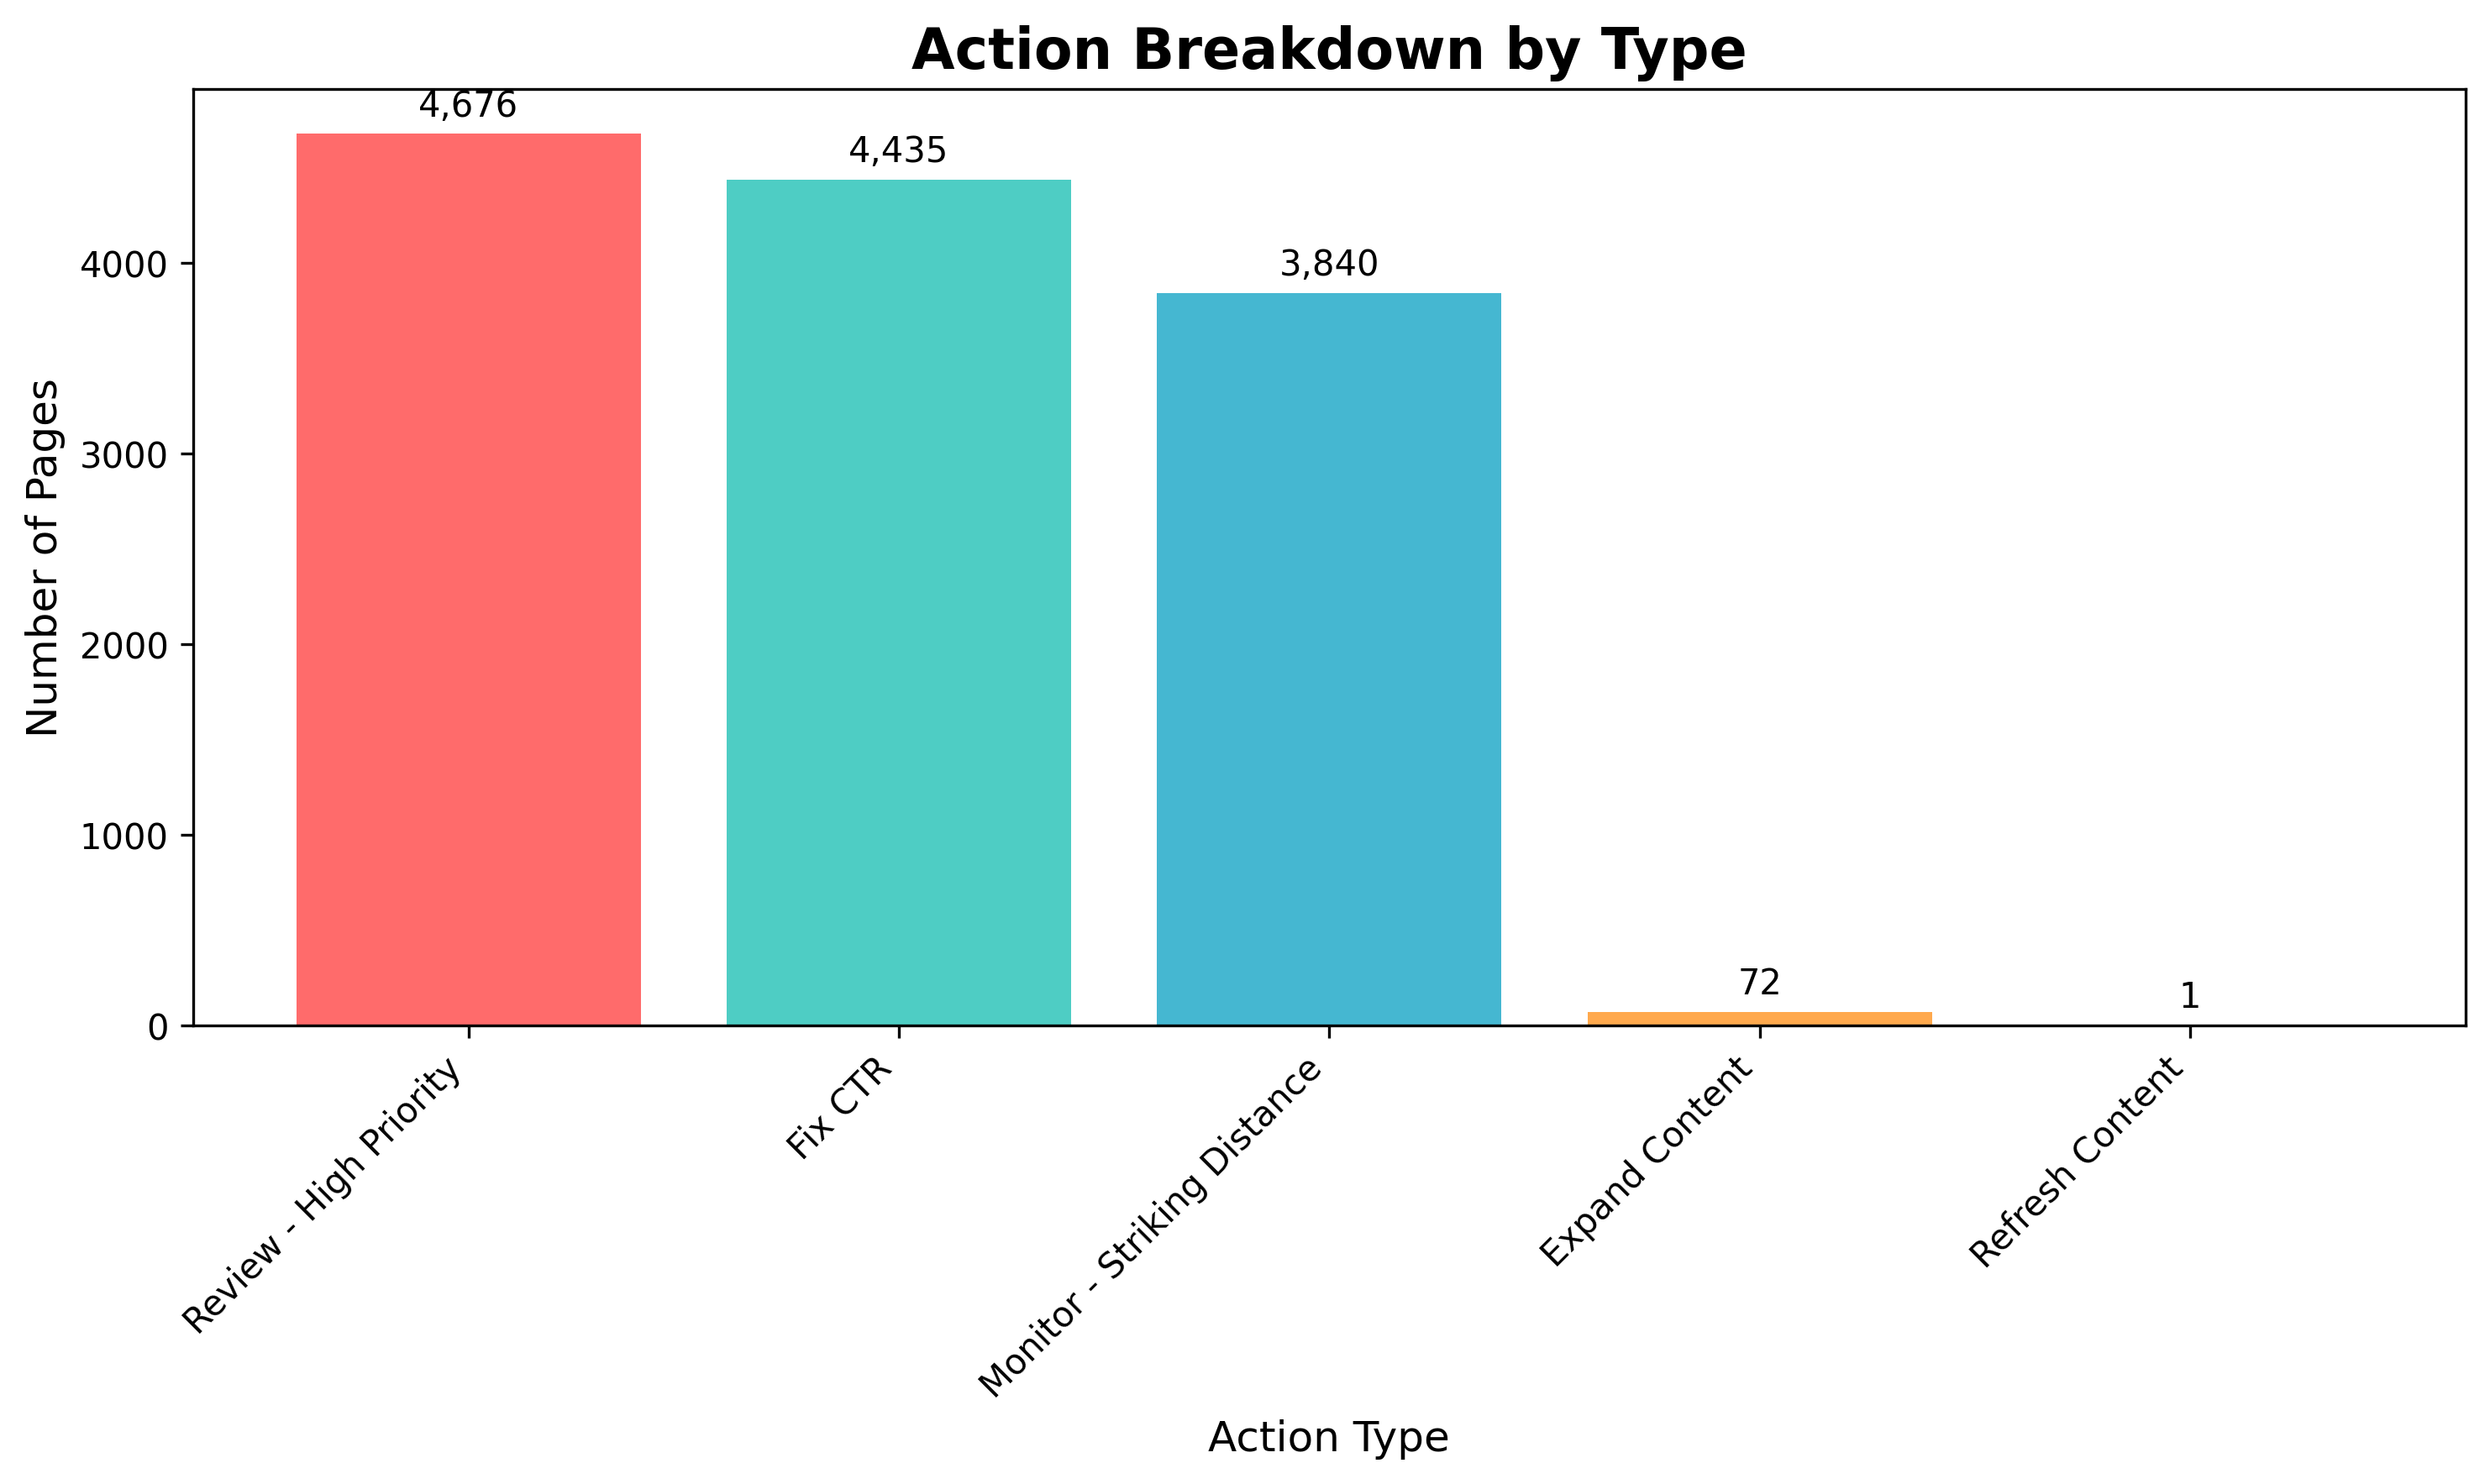


--- Table 1: Model Performance Summary ---

| Method | Precision@20 | Precision@50 |
|--------|--------------|--------------|
| Baseline (my rule) | 0.900 | 0.680 |
| Logistic Regression | 0.650 | 0.700 |

--- Table 2: Action Queue Summary ---

| Priority | Action | Count | Reason Code |
|----------|--------|-------|-------------|
| 1 | Review declining visible pages | 4676 | `declining_visible` |
| 2 | Fix CTR on page 1 pages | 4435 | `low_ctr_visible` |
| 3 | Monitor striking distance pages | 3840 | `striking_distance` |
| 4 | Expand thin visible pages | 72 | `thin_visible_page` |
| 5 | Refresh stale visible pages | 1 | `stale_visible_page` |

--- Artifact Locations ---
✅ Action Breakdown Chart: work/figures/action_breakdown.png
✅ Metrics JSON: work/outputs/playbook_metrics.json

Note: CSV files are blocked by the CI leak-guard and are not on GitHub.
The action queue summary table above contains the key numbers for the paper.


In [ ]:
# ============================================================
# 7. Artifacts the Paper Embeds
# ============================================================

import os
import json
import matplotlib.pyplot as plt
from IPython.display import Image, display

print("=" * 60)
print("Artifacts the Paper Embeds")
print("=" * 60)

# Create directories if they don't exist
os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

# ============================================================
# Download Files from GitHub (if not present)
# ============================================================

print("\n--- Checking for artifacts ---")

# Only download files that are ACTUALLY on GitHub
files_to_download = [
    ("work/figures/action_breakdown.png", "https://raw.githubusercontent.com/TemitopeAlawode/flyrank-ml-internship/main/work/figures/action_breakdown.png"),
    ("work/figures/action_breakdown_hires.png", "https://raw.githubusercontent.com/TemitopeAlawode/flyrank-ml-internship/main/work/figures/action_breakdown_hires.png"),
    ("work/outputs/playbook_metrics.json", "https://raw.githubusercontent.com/TemitopeAlawode/flyrank-ml-internship/main/work/outputs/playbook_metrics.json"),
]

for local_path, github_url in files_to_download:
    if not os.path.exists(local_path):
        print(f"📥 Downloading: {local_path}")
        !wget -q -O {local_path} {github_url}
    else:
        print(f"✅ Already exists: {local_path}")

# ============================================================
# Figure 1: Action Breakdown
# ============================================================

print("\n--- Figure 1: Action Breakdown ---")

fig_path = "work/figures/action_breakdown.png"
if os.path.exists(fig_path):
    print(f"✅ Figure found: {fig_path}")
    display(Image(fig_path))
else:
    print(f"⚠️ Figure not found: {fig_path}")

# ============================================================
# Table 1: Model Performance Summary
# ============================================================

print("\n--- Table 1: Model Performance Summary ---")

metrics_path = "work/outputs/playbook_metrics.json"
if os.path.exists(metrics_path):
    with open(metrics_path, 'r') as f:
        metrics = json.load(f)

    print("\n| Method | Precision@20 | Precision@50 |")
    print("|--------|--------------|--------------|")
    print(f"| Baseline (my rule) | {metrics['baseline']['precision_at_20']:.3f} | {metrics['baseline']['precision_at_50']:.3f} |")
    print(f"| Logistic Regression | {metrics['model']['precision_at_20']:.3f} | {metrics['model']['precision_at_50']:.3f} |")
else:
    print("⚠️ Metrics file not found")

# ============================================================
# Table 2: Action Queue Summary
# ============================================================

print("\n--- Table 2: Action Queue Summary ---")

action_summary = [
    {"Priority": 1, "Action": "Review declining visible pages", "Count": 4676, "Reason Code": "declining_visible"},
    {"Priority": 2, "Action": "Fix CTR on page 1 pages", "Count": 4435, "Reason Code": "low_ctr_visible"},
    {"Priority": 3, "Action": "Monitor striking distance pages", "Count": 3840, "Reason Code": "striking_distance"},
    {"Priority": 4, "Action": "Expand thin visible pages", "Count": 72, "Reason Code": "thin_visible_page"},
    {"Priority": 5, "Action": "Refresh stale visible pages", "Count": 1, "Reason Code": "stale_visible_page"}
]

print("\n| Priority | Action | Count | Reason Code |")
print("|----------|--------|-------|-------------|")
for item in action_summary:
    print(f"| {item['Priority']} | {item['Action']} | {item['Count']} | `{item['Reason Code']}` |")

# ============================================================
# Artifact Locations
# ============================================================

print("\n--- Artifact Locations ---")

artifacts = [
    ("Action Breakdown Chart", "work/figures/action_breakdown.png"),
    ("Metrics JSON", "work/outputs/playbook_metrics.json"),
]

for name, path in artifacts:
    if os.path.exists(path):
        print(f"✅ {name}: {path}")
    else:
        print(f"⚠️ {name}: {path} (not found)")

print("\n" + "=" * 60)
print("Note: CSV files are blocked by the CI leak-guard and are not on GitHub.")
print("The action queue summary table above contains the key numbers for the paper.")

## 8. 5-Minute Demo Outline

### Question (30 seconds)
*"Which search and content signals are most associated with page performance, and how can content teams use this to prioritize their work?"*

### Method (1 minute)
- **Data:** 30,000 pages from the FlyRank starter dataset
- **Features:** 14 signals (position, CTR, engagement, age, word count, consistency, etc.)
- **Approach:** Signal analysis + Logistic Regression, Decision Tree, Random Forest
- **Validation:** Client-holdout split (80/20 by client)

### One Chart (1 minute)
![Action Breakdown](https://github.com/TemitopeAlawode/flyrank-ml-internship/blob/main/work/figures/action_breakdown.png?raw=1)

*Figure: Distribution of 13,024 actionable pages across 5 action types.*

### One Honest Result (1.5 minutes)
| Method | Precision@20 | Precision@50 |
|---|---|---|
| Baseline (my rule) | **0.900** | 0.680 |
| Logistic Regression | 0.650 | **0.700** |

**The honest take:** Baseline is better at finding the absolute worst pages; Logistic Regression finds more bad pages overall.

### One Recommendation (1 minute)
> *"Use the baseline rule for the top 20 pages, and Logistic Regression for the next 30 pages. This combination gives you the best precision at both levels."*

**Total:** ~5 minutes

---

## 9. Shareable Cuts

### Social Post (Methodology Focus)

> *"I analyzed 30,000 search pages to find which signals actually predict decline. Position, consistency, and age were the top signals — but the simple rule ('stale + visible') still beats the model at finding the worst pages. Full paper: https://temitopealawode.github.io/flyrank-ml-internship/

### Employer 3-Sentence Summary

> *"I built a content performance model on 30,000 real search pages, comparing 3 ML methods against a simple baseline rule. The best model (Logistic Regression) achieved 70% precision at the top 50 recommendations, slightly improving over the baseline's 68%. The final output is a ranked action playbook that helps content teams prioritize which pages to review first."*

### One-Sentence Summary (for LinkedIn)

> *"Built a content review prioritization system on 30,000 search pages, finding that position and consistency are the strongest signals for predicting page decline."*

## 10. Reproducibility

All code, data processing, and analysis for this project are available in the following repository:

**GitHub Repository:** [https://github.com/TemitopeAlawode/flyrank-ml-internship](https://github.com/TemitopeAlawode/flyrank-ml-internship)

### Notebooks

| Notebook | Description |
|---|---|
| `w01_research_question.ipynb` | Research question framing |
| `w02_ml_task_framing.ipynb` | ML task mapping |
| `w03_data_contract.ipynb` | Data contract and leakage checks |
| `w04_baseline_score.ipynb` | Baseline rule and signal audit |
| `w05_model.ipynb` | Model training and comparison |
| `w06_validation_audit.ipynb` | Validation and claim audit |
| `w07_action_playbook.ipynb` | Action playbook |
| `capstone.ipynb` | Full research paper |

### How to Rerun

1. Clone the repository
2. Open the notebooks in Colab or Jupyter
3. Run cells in order
4. Results should match the paper

### Seeds and Versions

- Random seed: `42` (used throughout)
- Python 3.x with standard data science libraries (pandas, numpy, scikit-learn)

## 11. Acknowledgments & Data Credit

This research was built on the **FlyRank ML Internship dataset**, an anonymized export of real search and content performance data.

> **Data Credit:** Built on the [FlyRank ML Internship dataset](https://flyrank.ai). Used with permission under the internship data-use terms.

The dataset includes 30,000 pages with trailing 90-day metrics across 44 columns, including performance signals (impressions, clicks, CTR, position), content metadata (word count, content age, content type), and engagement signals (engagement rate, scroll rate).

All client names, domains, URLs, and raw queries were pseudonymized or removed before release. No private data appears in this analysis.

**Thank you to FlyRank for providing this data and making this internship possible.**

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.